# Forecasting Macroeconomic Trends: The Nexus of Exchange Rates, Energy, and CP

In [229]:
import pandas as pd 
import matplotlib.pyplot as plt 
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRFRegressor
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import yfinance as yf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from pmdarima.arima.utils import nsdiffs
from pmdarima import auto_arima

## 1. Data Collection

### 1.1 Inflation

In [189]:
# Inflation is pulled from bsp site.
# link: https://www.bsp.gov.ph/Statistics/Prices/tab34_inf_2018.aspx

inflation_df = pd.read_excel('Inflation_rates_dataset_2021-2026.xlsx')
inflation_df['month'] = pd.to_datetime(inflation_df['month']).dt.to_period('M').dt.to_timestamp()
inflation_df = inflation_df.set_index('month')

### 1.2 Sentiment Analysis

In [190]:
# Sentiment Analysis was scraped, cleaned, process in different .ipynb as it takes time to scrape headers
# Newsline headers source link: www.bworldonline.com/banking-finance/

sentiment_df = pd.read_csv('finBERT Sentiment-Inflation.csv')
sentiment_df['month'] = pd.to_datetime(sentiment_df['date']).dt.to_period('M').dt.to_timestamp()
sentiment_df = sentiment_df.drop(columns = ['date'], errors = 'ignore')

### 1.3 Oil Brent

In [191]:
oil_df = yf.download(tickers='BZ=F', start='2021-01-01', end = '2026-06-01', interval='1d')
oil_df = oil_df['Close'].resample('M').mean()
oil_df.columns = ['oil_brent']
oil_df = oil_df.reset_index()
oil_df['month'] = oil_df['Date']
oil_df = oil_df.drop(columns = 'Date', errors = 'ignore')
oil_df['month'] = pd.to_datetime(oil_df['month']).dt.to_period('M').dt.to_timestamp()

C:\Users\Marry Bless Magat\AppData\Local\Temp\ipykernel_25876\989090811.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil_df = yf.download(tickers='BZ=F', start='2021-01-01', end = '2026-06-01', interval='1d')
[*********************100%***********************]  1 of 1 completed


### 1.4 Merging dataframes

In [192]:
df = pd.merge(sentiment_df, oil_df, on='month', how='inner').drop(columns = 'inflation', errors='ignore').set_index('month')

In [193]:
print(f'Inflation Information:')
print(f'length: {len(inflation_df)}')
print(f'NAs: {inflation_df.isna().sum()}')
print('Head:')
print(inflation_df.head())
print('Tail:')
print(inflation_df.tail())
print('')
print(f'Exogenous Variables Information:')
print(f'Length: {len(df)}')
print(f'NAs: {df.isna().sum()}')
print('Head:')
print(df.head())
print('Tail:')
print(df.tail())

Inflation Information:
length: 63
NAs: inflation    0
dtype: int64
Head:
            inflation
month                
2021-01-01        3.7
2021-02-01        4.2
2021-03-01        4.1
2021-04-01        4.1
2021-05-01        4.1
Tail:
            inflation
month                
2025-11-01        1.5
2025-12-01        1.8
2026-01-01        2.0
2026-02-01        2.4
2026-03-01        4.1

Exogenous Variables Information:
Length: 65
NAs: sentiment    0
oil_brent    0
dtype: int64
Head:
            sentiment  oil_brent
month                           
2021-01-01  -0.096034  55.351579
2021-02-01   0.019575  62.227894
2021-03-01  -0.041243  65.702174
2021-04-01   0.023667  65.328572
2021-05-01  -0.017046  68.258500
Tail:
            sentiment   oil_brent
month                            
2026-01-01  -0.028967   64.765499
2026-02-01  -0.000079   69.406843
2026-03-01   0.023276   99.599546
2026-04-01   0.013479  102.464286
2026-05-01   0.078773  104.092000


## 2 Exploratory Data Analysis

### 2.1 Correlation Analysis and Stationarity Check

In [195]:
print('Energy vs Inflation correlation through lags:')
print('')
for lag in [0, 1, 2, 3, 4]:
    lagged_corr = inflation_df['inflation'].corr(df['oil_brent'].rolling(window = 3).mean().shift(lag))
    print(f"Oil Brent (Lag {lag}) vs Inflation Corr: {lagged_corr:.4f}")

print('')
print('Sentiment Analysis vs Inflation Correlation through lags:')
print('')
for lag in [0, 1, 2, 3, 4]:
    lagged_corr = inflation_df['inflation'].corr(df['sentiment'].rolling(window = 3).mean().shift(lag))
    print(f"Sentiment (Lag {lag}) vs Inflation Corr: {lagged_corr:.4f}")
print('')

print('ADF Test for stationarity checking') 

def adf_test(series):
    result = adfuller(series)[1]

    if result > 0.05:
        print(f'ADF: {result}, differencing is needed')
    else:
        print(f'ADF: {result}, no differencing needed. Data is stationary')

def ndiffs(series):
    result = nsdiffs(series, m=12, test='ocsb')
    print(f'Suggested Seasonal Differencing: {result}')
adf_test(inflation_df['inflation'])
ndiffs(inflation_df['inflation'])

Energy vs Inflation correlation through lags:

Oil Brent (Lag 0) vs Inflation Corr: 0.6226
Oil Brent (Lag 1) vs Inflation Corr: 0.6493
Oil Brent (Lag 2) vs Inflation Corr: 0.6735
Oil Brent (Lag 3) vs Inflation Corr: 0.7006
Oil Brent (Lag 4) vs Inflation Corr: 0.7229

Sentiment Analysis vs Inflation Correlation through lags:

Sentiment (Lag 0) vs Inflation Corr: 0.4130
Sentiment (Lag 1) vs Inflation Corr: 0.4294
Sentiment (Lag 2) vs Inflation Corr: 0.4417
Sentiment (Lag 3) vs Inflation Corr: 0.4162
Sentiment (Lag 4) vs Inflation Corr: 0.3793

ADF Test for stationarity checking
ADF: 0.13346084422113258, differencing is needed
Suggested Seasonal Differencing: 0


C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


### 2.2 ACF/PACF Plots

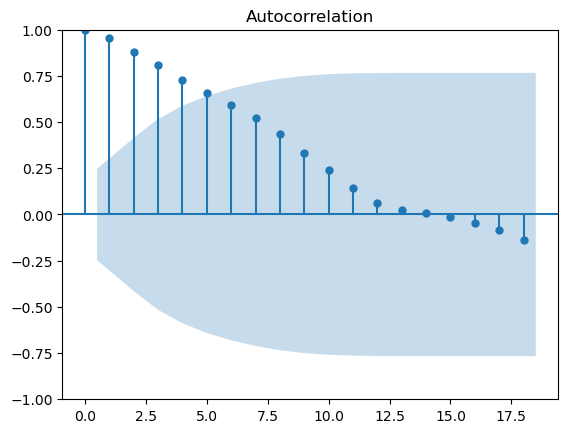

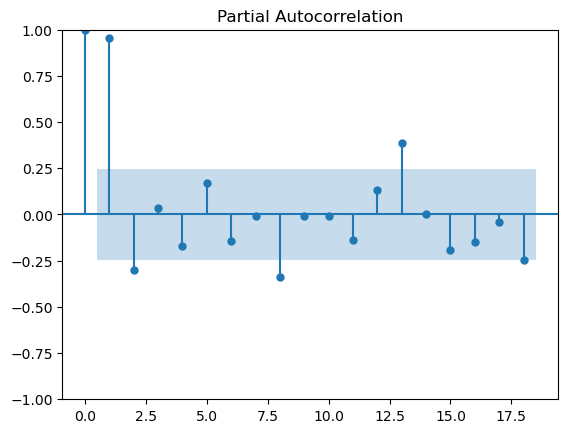

In [198]:
plot_acf(inflation_df['inflation'])
plot_pacf(inflation_df['inflation'])

plt.show()



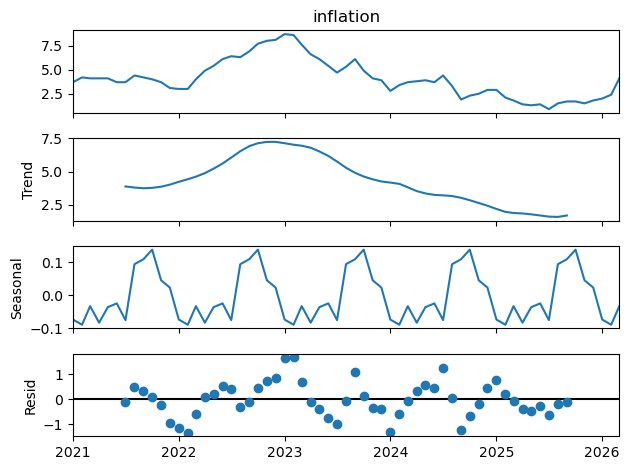

In [233]:
decomp = seasonal_decompose(inflation_df['inflation'], model = 'additive', period = 12)

decomp.plot()
plt.tight_layout()
plt.show()

# This shows that nsdiffs prove that no Seasonal Differencing needed
# Other tests like ACF and PACF and Seasonal Decomposition shows that there is a weak seasonality.
# Auto ARIMA will be used and make sure that Seasonal Differencing is not included

## 3. Feature Engineering

### 3.1 Train/Test Split

In [270]:
split = int(len(inflation_df)* 0.8)

inflation_train = inflation_df.iloc[0:split]
inflation_test = inflation_df.iloc[split:]

feature_train = df.iloc[0:split]
feature_test = df.iloc[split:]

print(f'Inflation Split: Train={len(inflation_train)}, Test={len(inflation_test)}')
print(f'Feature Split: Train={len(feature_train)}, Test{len(feature_test)}')

Inflation Split: Train=50, Test=13
Feature Split: Train=50, Test15


### 3.2 Feature Engineering

In [271]:
feature_train['sentiment'] = feature_train['sentiment'].rolling(window=3).mean().shift(2)
feature_train['oil_brent'] = feature_train['oil_brent'].rolling(window=3).mean().shift(2)
feature_train = feature_train.dropna()

feature_test['sentiment'] = feature_test['sentiment'].rolling(window=3).mean().shift(2)
feature_test['oil_brent'] = feature_test['oil_brent'].rolling(window=3).mean().shift(2)
feature_test = feature_test.dropna()

# Aligning Feature timestamps to eliminate timevoid 
last_date = feature_train.index[-1]
index_range = pd.date_range(start=last_date, periods=len(feature_test)+1, freq='MS')[1:]
feature_test = feature_test.set_index(index_range)

# Securing Future Feature
X_future = feature_test[-2:]
feature_test = feature_test[:-2]

# Matching the Inflation dataset timestamp to feature engineered data 
inflation_train = inflation_train.loc[inflation_train.index.isin(feature_train.index)]
inflation_test = inflation_test.iloc[inflation_test.index.isin(feature_test.index)]





print(f'Inflation Split: Train={len(inflation_train)}, Test={len(inflation_test)}')
print(f'Feature Split: Train={len(feature_train)}, Test= {len(feature_test)}')
print(f'Future Feature: {len(X_future)}')

Inflation Split: Train=46, Test=9
Feature Split: Train=46, Test= 9
Future Feature: 2


C:\Users\Marry Bless Magat\AppData\Local\Temp\ipykernel_25876\4270761234.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feature_train['sentiment'] = feature_train['sentiment'].rolling(window=3).mean().shift(2)
C:\Users\Marry Bless Magat\AppData\Local\Temp\ipykernel_25876\4270761234.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feature_train['oil_brent'] = feature_train['oil_brent'].rolling(window=3).mean().shift(2)
C:\Users\Marry Bless Magat\AppData\Local\Temp\ipykernel_25876\4270761234.py:5: Set

In [267]:
feature_test

,sentiment,oil_brent
2025-03-01,0.012431,67.298095
2025-04-01,-0.034575,66.592381
2025-05-01,-0.082713,67.624507
2025-06-01,-0.044710,68.721491
2025-07-01,-0.091018,68.121014
2025-08-01,-0.075687,66.254637
2025-09-01,-0.089042,65.060652
2025-10-01,-0.039849,63.087341
2025-11-01,-0.023607,63.357870


In [268]:
inflation_test

,inflation
month,
2025-03-01,1.8
2025-04-01,1.4
2025-05-01,1.3
2025-06-01,1.4
2025-07-01,0.9
2025-08-01,1.5
2025-09-01,1.7
2025-10-01,1.7
2025-11-01,1.5


### 3.4 Test/Train Visualization

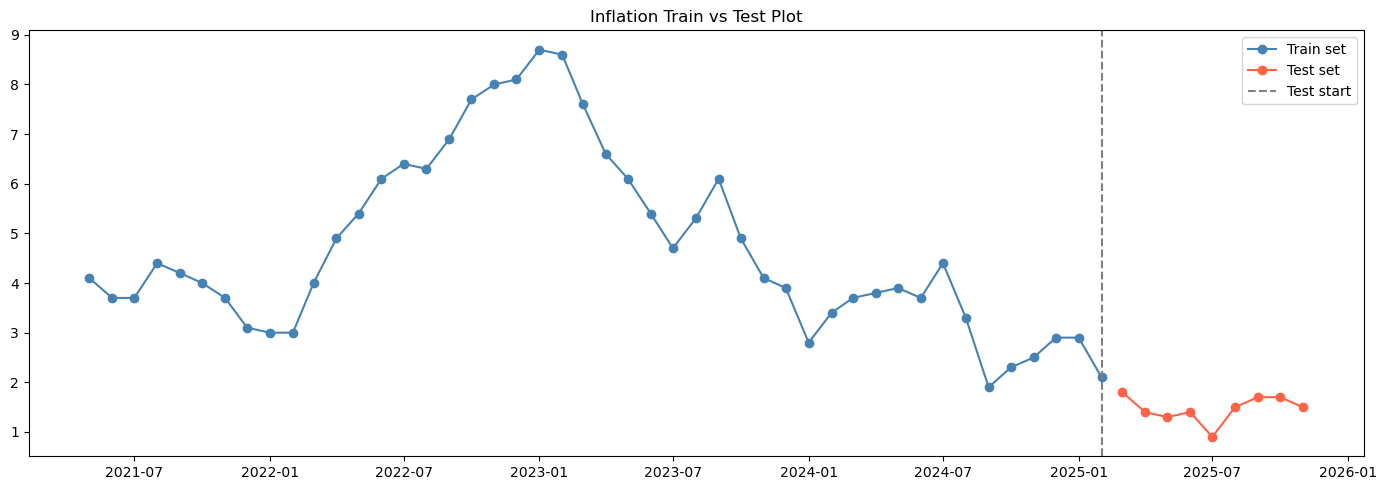

In [273]:
fig, ax = plt.subplots(figsize=(14,5))
ax.plot(inflation_train['inflation'], color = 'steelblue', label = 'Train set', marker = 'o')
ax.plot(inflation_test['inflation'], color = 'tomato', label = 'Test set', marker = 'o')

ax.axvline(last_date, color = 'grey', label = 'Test start', linestyle ='--')
ax.set_title('Inflation Train vs Test Plot')

plt.legend()
plt.tight_layout()
plt.show()

## 4. Modeling

#### 4.1 SARIMA Modeling 

In [277]:
arima_model = auto_arima(inflation_train['inflation'],
                         seasonal = True,    # Seasonality is weak but there's signal so we want to capture it
                         m=12,               # For monthly data
                         d=1,                # ADF test proved that differencing is needed 
                         D=0,                # nsdiff proved that seasonal differencing is not needed
                         max_p=3,
                         max_q=3,
                         max_P=2,
                         max_Q=2,
                         stepwise=False,     # For exhaustive search instead of stepwise
                         information_criterion='aic')

C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in

#### 4.2 Model Summary and Plot

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                   46
Model:             SARIMAX(1, 1, 1)x(2, 0, [], 12)   Log Likelihood                 -28.007
Date:                             Tue, 02 Jun 2026   AIC                             68.015
Time:                                     22:51:02   BIC                             78.855
Sample:                                 05-01-2021   HQIC                            72.056
                                      - 02-01-2025                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.1367      0.207     -0.659      0.510      -0.543       0.270
ar.L1         -0.4972      

C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


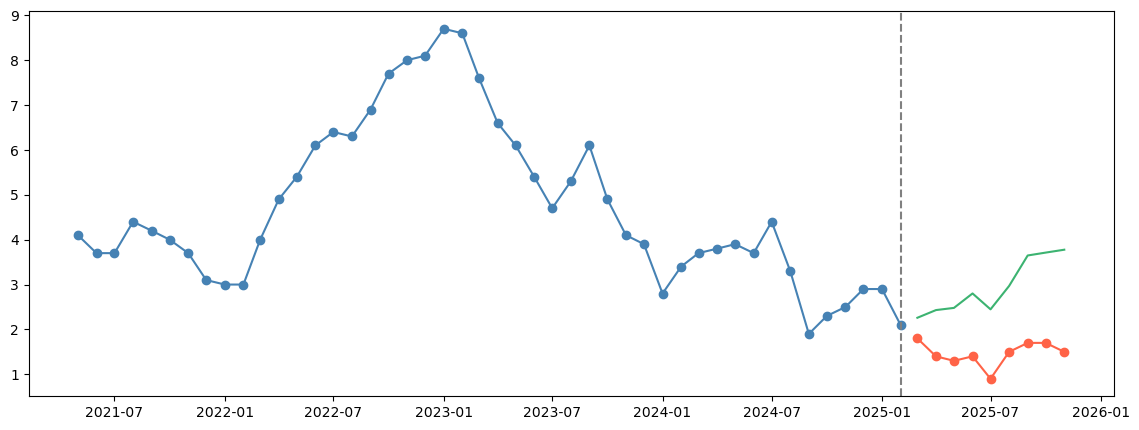

In [278]:
print(arima_model.summary())

forecast, conf_int = arima_model.predict(len(inflation_test), return_conf_int=True)
forecast_df = pd.DataFrame({
    'forecast' : forecast.values,
    'lower_ci' : conf_int[:,0],
    'upper_ci' : conf_int[:,1]}, index=inflation_test.index
                          )

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(inflation_train['inflation'], color = 'steelblue', label = 'Train set', marker = 'o')
ax.plot(inflation_test['inflation'], color = 'tomato', label = 'Test set', marker = 'o')
ax.plot(forecast_df['forecast'], color = 'mediumseagreen', label = 'Test Forecast')

ax.axvline(last_date, color = 'grey', label = 'Test start', linestyle ='--')
plt.show()


In [253]:
arima_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                   46
Model:             SARIMAX(1, 1, 1)x(2, 0, [], 12)   Log Likelihood                 -28.007
Date:                             Tue, 02 Jun 2026   AIC                             68.015
Time:                                     22:36:01   BIC                             78.855
Sample:                                 05-01-2021   HQIC                            72.056
                                      - 02-01-2025                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.1367      0.207     -0.659      0.510      -0.543       0.270
ar.L1         -0.4972      0.249     -1.999      0.046      -0.985      -0.010
ma.L1          0.9723      0.275      3.532      0.000       0.433       1.512
ar.S.L12      -0.7705      0.187     -4.114      0.000      -1.138      -0.403
ar.S.L24      -0.3869      0.250     -1.545      0.122      -0.878       0.104
sigma2         0.1588      0.049      3.232      0.001       0.063       0.255
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 0.49
Prob(Q):                              0.90   Prob(JB):                         0.78
Heteroskedasticity (H):               1.24   Skew:                             0.20
Prob(H) (two-sided):                  0.68   Kurtosis:                         2.67
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""